# XGBoost Regressor

## Import Required Libraries

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

/Users/alanabarrett-frew/Developer/Module2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning with GridSearchCV

In [5]:
xgb_model = XGBRegressor(n_estimators=1000, max_depth=7, learning_rate=0.1, subsample=0.7, colsample_bytree=0.8, random_state=456, n_jobs=-1)
xgb_model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Save the Trained Model

In [6]:
joblib.dump(xgb_model, '../../models/xgb_model.joblib')

['../../models/xgb_model.joblib']

## Evaluate Results

In [7]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R^2 Score: {r2:.2f}")

y_train_pred = xgb_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.32162097096443176
MSE: 0.1739925891160965
RMSE: 0.4171241890805381
R^2 Score: 0.99
Train MAE: 0.00, Train R^2: 1.00
Test MAE: 0.32, Test R^2: 0.99


In [8]:
results = {
    'Model': 'XGBRegressor',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(xgb_model.get_params()),
    'Notes': ''
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

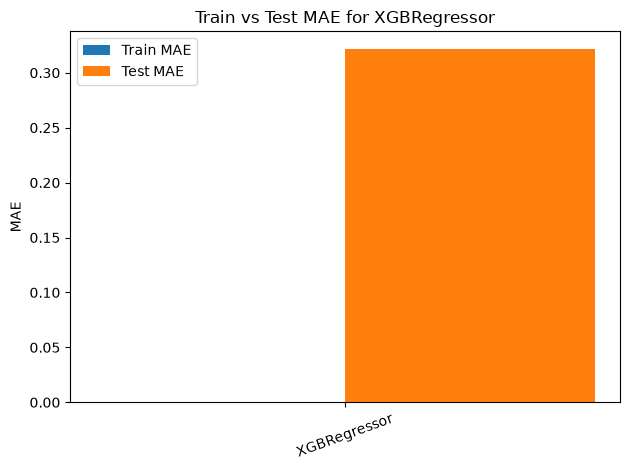

In [10]:
import matplotlib.pyplot as plt

# Visualize train vs test MAE for the XGBRegressor model

models = ['XGBRegressor']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for XGBRegressor')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualisation

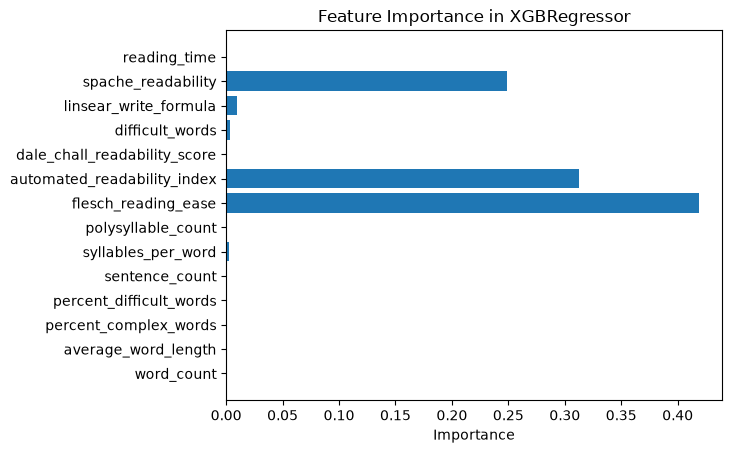

In [11]:
import matplotlib.pyplot as plt

plt.barh(feature_columns, xgb_model.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance in XGBRegressor")
plt.show()

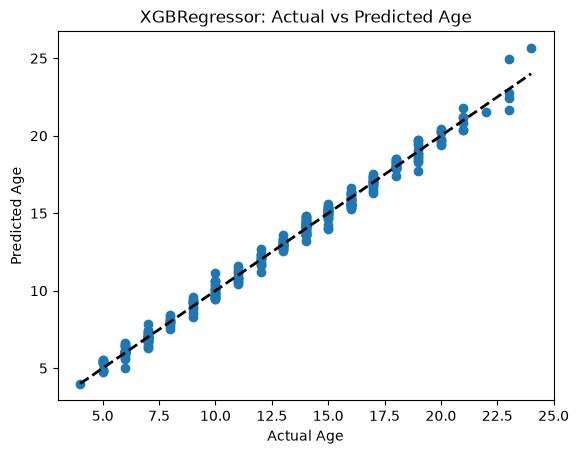

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("XGBRegressor: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()